# Introduction:

In this project, I will be applying three curve fitting and data interpolation methods to economic data provided by the U.S. Bureau of Economic Analysis. The data itself consists of a number of GDP Growth rates from the first Quarter of 2010 to the fourth Quarter of 2023, though the data for a number of quarters is not present. The three methods I will apply are a cubic spline interpolation, a 4th degree polynomial least squares fit, and a linear least squares Fit. The cubic spline interpolation utilizes a system of equations and a number of conditions to create derivatives and then equations for curves that will pass smoothly between each individual point. The polynomial fit will generate a Vandermonde matrix that will be used to generate coefficients for a 4th degree polynomial fitted to the data that is then plotted alongside it. Lastly, the linear least squares fit seeks to create a line with that minimizes the squared residuals between itself and the given values, which is applied to model a linear relationship for the data. I will ultimately seek to see how effective these methods are at interpolating and representing data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A: Cubic Spline Interpolation

### Interpolation Functions:

In [2]:
def setup_tridiagonal_matrix(x, y):
    
    n = len(x)
    
    h = np.diff(x) # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1])) # Right-hand side vector
    
    return A, B, C, D


In [3]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x

In [4]:
"""
My initial function that I copied from my HW6 was not working with the data. I suspected it had something to do with 
the fact that the data for this project consisted of floats, and on the homework I only tested integers. I couldn't
figure out how to fix it, so I ended up asking the AI Claude what was wrong with it, and then implemented its 
recommendations to test it, which worked. The prompt I used was 'Can you help me debug a function that is meant to 
create a cubic spline interpolation for a given set of data?' followed by my old code. It gave me a list of the 
present bugs as well as recommendations on how to fix them, which I then followed.
"""

def evaluate_spline(x_data, y_data):

    a, b, c, d = setup_tridiagonal_matrix(x_data, y_data)
    M = np.array([0.0, *thomas_algorithm(a, b, c, d), 0.0], dtype=float) # Computing second derivatives

    length = 0
    for i in range(len(x_data) - 1):
        length += int(round((x_data[i+1] - x_data[i]) * 100))

    yspline = np.zeros(length)
    xspline = np.linspace(x_data[0], x_data[-1], length)

    idx = 0
    for i in range(len(x_data) - 1): # Evaluating the polynomial formula on each interval
        segment_len = int(round((x_data[i+1] - x_data[i]) * 100))

        x_interp = np.linspace(x_data[i], x_data[i+1], segment_len, endpoint=False)

        dxright = x_data[i+1] - x_interp
        dxleft  = x_interp   - x_data[i]
        hi      = x_data[i+1] - x_data[i]

        yspline[idx : idx + segment_len] = (
            (M[i]   / (6*hi)) * dxright**3 +
            (M[i+1] / (6*hi)) * dxleft**3  +
            (y_data[i]   / hi - (M[i]   * hi) / 6) * dxright +
            (y_data[i+1] / hi - (M[i+1] * hi) / 6) * dxleft
        )

        idx += segment_len

    return xspline, yspline

For the system of equations that must be solved to create a cubic spline interpolation, there are n-2 unknowns where n is the number of data points. The second derivatives within the data are being solved for. At the endpoints they are zero, so there are two less unknowns than the total points. As such, the specific system that will be solved for this data will be size 18x18. At each knot there are three continuity conditions. The spline itself must be continuous, the first derivative must be continuous, and the second derivative must be continuous. These three conditions ensure that each individual curve is smooth, and that sharp changes of direction or loss of smoothness does not occur at any of the knots. The boundary conditions that define a natural spline are that the second derivative is equal to zero at each end of the data, causing the spline to behave linearly beyond this.

### Given Data:

In [5]:
quarters = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56], dtype=float)
gdpgrowth = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

### Interpolation and Plotting:

In [6]:
interp_quarters, interp_growth = evaluate_spline(quarters, gdpgrowth)

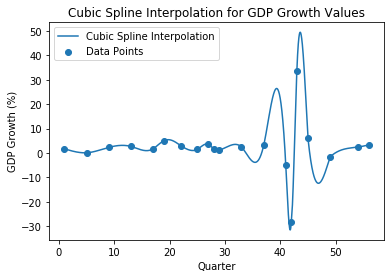

In [7]:
plt.figure()
plt.title("Cubic Spline Interpolation for GDP Growth Values")
plt.scatter(quarters, gdpgrowth, label="Data Points")
plt.plot(interp_quarters, interp_growth, label="Cubic Spline Interpolation")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.show()

The plotted interpolant is very smooth visually, and is able to connect every point. It is reasonable for the most part, though it encounters significant oscillation during the COVID Quarters as the data points here have much larger magnitudes than the rest of the set. This oscillation is reminiscent of the Runge Phenomenon, and it significantly reduces the interpolant's ability to represent unknown values between outliers within the data set, similarly to how high degree polynomial fits can oscillate wildly outside of given data. The trade-off of exact interpolation of the given data is that there will be significant error in data near the outliers. Smoothing splines and weighted least squares would both be preferable here. Applying smoothing splines would mean the curve doesn't directly pass through the furthest data points and would thus be smoother around them, ideally creating more accurate estimates of economic data. Weighted least squares could achieve a similar affect by reducing the weight of the data from the COVID quarters.

## Part B: Polynomial and Least Squares Fit

### Functions:

In [8]:
def polyfit(X, Y):
    # Create Vandermonde matrix for a polynomial of degree 4
    degree = 4
    V = np.vander(X, N=degree+1, increasing=True)
    # V.T * V
    VT_V = np.dot(V.T, V)
    # V.T * y
    VT_y = np.dot(V.T, Y)
    # Solve normal equations for a (coefficients)
    coefficients = np.linalg.solve(VT_V, VT_y)
    print(f"Polynomial Coefficients: {coefficients}")
    polynomial = np.poly1d(coefficients[::-1])

    y_pred = polynomial(X)
    
    return y_pred

In [9]:
def lstsqr(x, y):
    # Calculating slope and intercept by minimizing the sum of squared residuals
    xmean = np.mean(x)
    ymean = np.mean(y)
    mnum = np.sum((x-xmean)*(y-ymean))
    mdem = np.sum((x-xmean)**2)
    m = mnum/mdem
    b = ymean - m*xmean
    return m, b

### 4 Degree Polynomial Fit:

Polynomial Coefficients: [ 2.11403340e-01  4.12733208e-01 -2.11036921e-02  3.57892276e-04
 -1.71060095e-06]


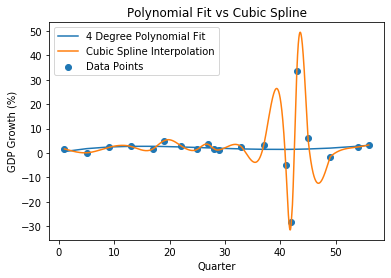

In [10]:
y_pred = polyfit(quarters, gdpgrowth)

plt.figure()
plt.title("Polynomial Fit vs Cubic Spline")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.scatter(quarters, gdpgrowth, label="Data Points")
plt.plot(quarters, y_pred, label="4 Degree Polynomial Fit")
plt.plot(interp_quarters, interp_growth, label="Cubic Spline Interpolation")
plt.legend()

The polynomial fit seemed to provide a better representation of the overall trend of the data, while the Cubic Spline Interpolation is better at reproducing specific points as it has to pass through every individual point. There are a number of trade-offs between the two methods as well. Approximation via the polynomial fit gives a better sense of the overall trend of the data, and is able to handle the outliers well. I believe interpolation is useful in that it is more capable of predicting a growth value between two known data points to an extent. When not passing through the COVID outliers, it provides a smooth path from point to point, and it is very plausible that unknown points could lie on that path. Unfortunately, this falls apart during the COVID quarters as the curves oscillate significantly before and after them. I severely doubt that there was a GDP Growth value of over 20% at any point between 2019 Q1 and 2020 Q1, and the cubic spline interpolation falls short to the polynomial fit as a tool of prediction in the presence of such drastic outliers.

#### Polynomial Fit Residual Plot and RMSE Calculation:

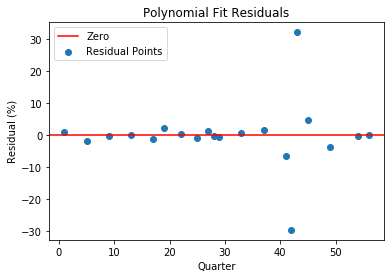

In [11]:
residuals = gdpgrowth - y_pred
plt.figure()
plt.scatter(quarters, residuals, label="Residual Points")
plt.axhline(0, color='r', label="Zero")
plt.title('Polynomial Fit Residuals')
plt.xlabel('Quarter')
plt.ylabel('Residual (%)')
plt.legend()
plt.show()

In [12]:
polyrmse = np.sqrt(np.mean(residuals**2))
print(f"Polynomial Fit RMSE: {polyrmse}")

Polynomial Fit RMSE: 10.031440678677114


Of note, the RMSE for the polynomial fit is somewhat high at 10.031. This is expected due to the presence of the outliers of the COVID Quarters, and I imagine it would be much lower if they were not included.

### Least Squares Linear Fit:

In [13]:
# Data Excluding the COVID Quarters
quarters_nocovid = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 49, 54, 56], dtype=float)
growth_nocovid = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])

In [14]:
m, b = lstsqr(quarters_nocovid, growth_nocovid)
print(f"Calculated Slope: {m}, Calculated Intercept: {b}")

lingrowth = m*quarters_nocovid + b

Calculated Slope: -0.0019069881889763798, Calculated Intercept: 2.194285187007874


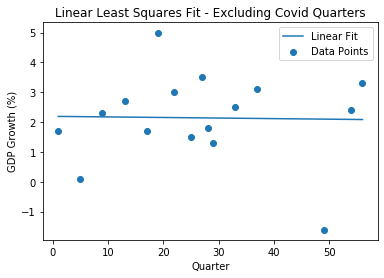

In [15]:
plt.figure()
plt.title("Linear Least Squares Fit - Excluding Covid Quarters")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.scatter(quarters_nocovid, growth_nocovid, label="Data Points")
plt.plot(quarters_nocovid, lingrowth, label="Linear Fit")
plt.legend()

I think that a linear trend does make sense for this data in a limited capacity. The slope of the fit line was -0.0019. This is very close to zero and seems to imply that growth rates remained relatively stable over this time period. However, this excludes the effects of COVID entirely. As such, I believe a linear fit's application data like this mostly has value as a way to determine if growth was stable during this time. A slope near zero indicates stability, while a slope far from zero would likely indicate rapidly increasing or decreasing growth from an economic boom or downturn. This is because a linear least squares fit relies on the assumption that the relationship in the data is linear, and this generally is not true in economics. Because of this, any such linear fit has little value as a predictive model.

#### Linear Fit Residuals Plot and RMSE Calculation:

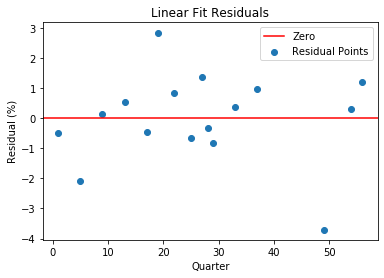

In [16]:
linresiduals = growth_nocovid - lingrowth
plt.figure()
plt.scatter(quarters_nocovid, linresiduals, label="Residual Points")
plt.axhline(0, color='r', label="Zero")
plt.title('Linear Fit Residuals')
plt.xlabel('Quarter')
plt.ylabel('Residual (%)')
plt.legend()
plt.show()

In [17]:
linrmse = np.sqrt(np.mean(linresiduals**2))
print(f"Linear Fit RMSE: {linrmse:.4f}")

Linear Fit RMSE: 1.4432


The RMSE for the linear fit was much smaller than the polynomial fit, at 1.4432, and its residuals were much closer to zero. This is expected due to the exclusion of the COVID Quarters, as most of the data points for GDP growth other than those are relatively close to the fit line.

# Part C: Method Justification:

If I had to recommend a method for a policymaker to use to estimate GDP growth for a quarter between two known points, I would recommend using a cubic spline interpolation. It provides a smooth path between each point that another point could plausibly lie on and is fully accurate to the given data. Its RMSE value at the known points is 0 which is by default lower than any polynomial fit. It is however, very susceptible to outliers, and oscillates wildly around the COVID quarters, greatly reducing the accuracy of any estimated data point. However, the polynomial fit does not do better here either, as it ignores the outliers, meaning any estimation of growth during this time based on it would be far from the economic disruption caused by COVID. Due to the inherent unpredictability of outside economic disruption like the COVID Pandemic, it is difficult for any such model to predict GDP growth during such a time.

### Big O Consideration:

Big O Notation describes how an algorithm's runtime changes as the size of its input n grows. It is very important in considering what algorithms to use, as a poorly scaled Big O can take an immense amount of computational power and time.
For the cubic spline interpolation Big O is effectively O(n). In the evaluate_spline function itself, Big O is O(n) based on the range of the data inputted. For both the tridiagonal system and thomas algorithms, Big O is also O(n) as they do not utilize nesting.
For the 4 degree polynomial fit, I also found Big O to be O(n); degree is fixed so it iterates linearly.
Big O is also O(n) for the linear fit, as it lacks any nesting.
With these considerations in mind, I would not change my recommendation, as Big O for both the cubic spline interpolation and the 4 degree polynomial fit scale linearly.

# Conclusion:

In this project, I was able to successfully apply three different curve fitting and data interpolation methods to economic data provided by the U.S. Government. Each method performed differently for different goals and had their own strengths and weaknesses. The cubic spline interpolation proved to be the most effective for predicting unknown data points between the given data. Its conditions ensured that a smooth curve passed through each point and minimized RMSE. It struggled with handling the data from COVID however, oscillating wildly around those quarters. The 4th degree polynomial, while not as effective at interpolation, provided a more accurate representation of the trend of the data. It was able to reduce the effect of the COVID outliers, and did not oscillate wildly at any point, however this came at a cost of higher RMSE and an inability to pass through specific points. The linear fit ultimately had little value as both an interpolant or approximation as it was outperformed in these respects by the other methods, and it assumes a linear relationship between GDP growth and time. I do believe, however, that it retains some value as a way to measure economic stability over a measured time period, but I would not recommend using it for anything beyond this. Ultimately, I was able to utilize a number of different data interpolation methods, and I found that there is no single best one. They all have drawbacks, and one must choose their method base on their goal for the data.